# 20. 바깥 시험 두 개: RGB와 MuSiQue

MK1 v2는 **Gemma 4 E2B(말하기 위성)** 둘레에 작은 전문 위성들을 붙인 시스템이야. Gemma는 말만 하고, 읽기·판단은 위성이 맡아.
이번엔 남이 만든 시험 두 개로 냉정하게 쟀어. 비교 상대는 **Gemma E2B 혼자**(MK1 안에 든 그 LLM)와 **Gemma E4B 혼자**(비슷한 메모리 예산의 더 큰 모델).

- **RGB**: 문서를 주고 묻는 시험. 잡음 섞인 문서, 답이 없는 문서(거절해야 함), 거짓 문서, 여러 문서 합치기.
- **MuSiQue-Full**: 여러 단계로 생각해야 하는 문제 + 답이 빠진 쌍둥이 문제. 여기엔 HotpotQA로 배운 **생각 위성**을 붙였어.

채점은 하나로 통일: **맞으면 +1, 모른다고 하면 0, 틀리면 −1** (순점수). 봉인분은 시스템을 얼린 뒤 딱 한 번 열었어. 그래서 **봉인 결과가 본 결과**고, 개발용은 참고야.
막대 위 오차 막대는 문제 단위로 짝지은 부트스트랩 95% 구간이야.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary_external as X
from cognitive_lab import viz as V
V.setup()
COLORS = {"e2b": V.NEUTRAL, "e4b": V.ORANGE, "mk1": V.BLUE, "mk1-think": V.BLUE}
rgb = X.rgb_verdict(); mus = X.musique_verdict()
print("RGB 봉인 평균 순점수:", rgb["mean_net"])
print("MuSiQue 봉인 순점수:", {k: v["net"] for k, v in mus["summary"].items()})


def diff_panel(ax, diffs, title):
    """MK1 minus each Gemma, with the paired bootstrap 95% interval."""
    rows = [("e2b", "MK1 - E2B 혼자"), ("e4b", "MK1 - E4B 혼자")]
    for y, (k, label) in enumerate(rows):
        d = diffs[k]
        win = d["low"] > 0; lose = d["high"] < 0
        color = V.BLUE if win else (V.ORANGE if lose else V.MUTED)
        ax.errorbar(d["point"], y, xerr=[[d["point"] - d["low"]], [d["high"] - d["point"]]], fmt="o", color=color,
                    ms=8, capsize=5, lw=2)
        verdict = "이김" if win else ("짐" if lose else "비김")
        ax.text(d["high"] + 0.008, y, f"{d['point']:+.3f}  ({d['low']:+.3f}, {d['high']:+.3f})  {verdict}",
                va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
    ax.axvline(0, color=V.TEXT_SECONDARY, lw=1)
    ax.set_yticks(range(len(rows)), [r[1] for r in rows]); ax.set_ylim(-0.6, len(rows) - 0.4); ax.invert_yaxis()
    ax.grid(axis="y", visible=False); ax.set_xlabel("순점수 차이")
    ax.set_title(title, pad=10)

RGB 봉인 평균 순점수: {'mk1': 0.4414, 'e2b': 0.3475, 'e4b': 0.4401}
MuSiQue 봉인 순점수: {'mk1-think': 0.5056, 'e2b': 0.5133, 'e4b': 0.5867}


## 1. RGB: 큰 그림

같은 Gemma E2B에 위성을 붙이니 **+0.094**. 더 큰 E4B와는 **비겼어**(0.441 vs 0.440). 작은 LLM을 품고도 큰 모델과 같은 점수, 하지만 이기진 못했어.

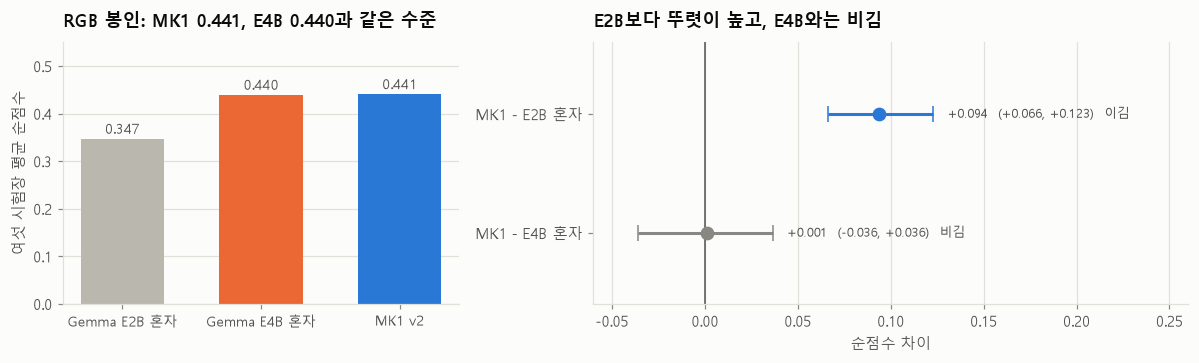

In [2]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1, 1.5]})
order = ["e2b", "e4b", "mk1"]
vals = [rgb["mean_net"][k] for k in order]
a1.bar(range(3), vals, color=[COLORS[k] for k in order], width=0.6)
for i, v in enumerate(vals):
    a1.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
a1.set_xticks(range(3), [X.SYSTEM_LABELS[k] for k in order], fontsize=9); a1.set_ylim(0, 0.55)
a1.grid(axis="x", visible=False); a1.set_ylabel("여섯 시험장 평균 순점수")
a1.set_title("RGB 봉인: MK1 0.441, E4B 0.440과 같은 수준", pad=10)
diff_panel(a2, rgb["diffs"], "E2B보다 뚜렷이 높고, E4B와는 비김")
a2.set_xlim(-0.06, 0.26)
fig.tight_layout(); plt.show()

## 2. RGB: 어디서 얻고 어디서 잃었나

시험장 여섯 개를 따로 보면 그림이 갈려. **거절**에서 크게 얻고, **정보 합치기**와 **잡음 80%**에서 잃었어. 거짓 문서는 셋 다 전혀 못 잡아.

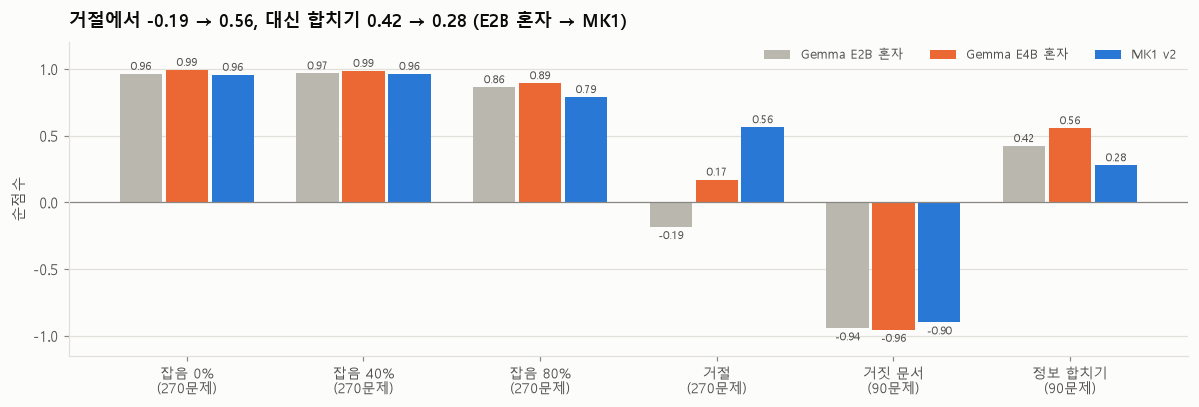

In [3]:
tb = X.RGB_TESTBEDS
fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(len(tb)); w = 0.26
for i, k in enumerate(order):
    vals = [rgb["per_testbed"][k][t] for t, _ in tb]
    ax.bar(x + (i - 1) * w, vals, width=w - 0.02, color=COLORS[k], label=X.SYSTEM_LABELS[k])
    for xi, v in zip(x, vals):
        ax.text(xi + (i - 1) * w, v + (0.03 if v >= 0 else -0.09), f"{v:.2f}", ha="center", fontsize=7.5,
                color=V.TEXT_SECONDARY)
ax.axhline(0, color=V.MUTED, lw=0.8)
ax.set_xticks(x, [f"{lab}\n({rgb['questions'][t]}문제)" for t, lab in tb], fontsize=9)
ax.set_ylim(-1.15, 1.2); ax.grid(axis="x", visible=False); ax.set_ylabel("순점수")
ax.legend(fontsize=8.5, loc="upper right", ncol=3, bbox_to_anchor=(1, 1.02))
ax.set_title("거절에서 -0.19 → 0.56, 대신 합치기 0.42 → 0.28 (E2B 혼자 → MK1)", pad=10)
fig.tight_layout(); plt.show()

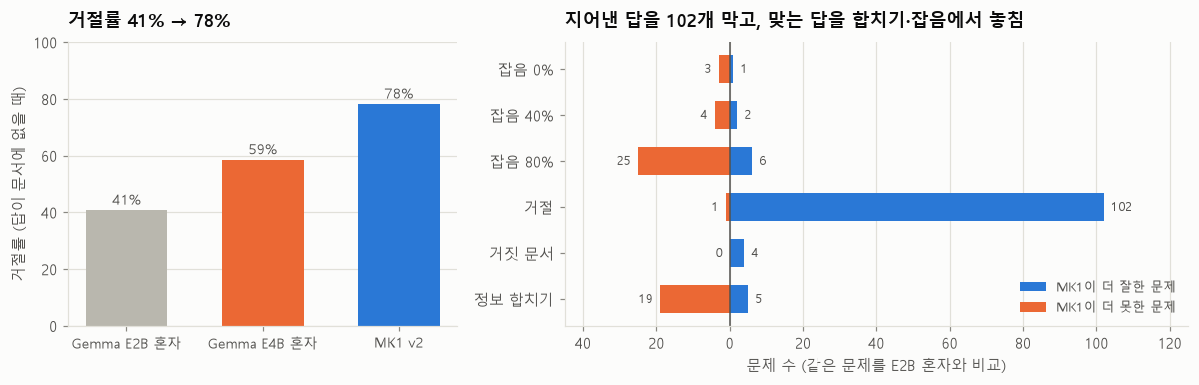

In [4]:
off = X.rgb_official("final"); gl = X.rgb_gain_loss("e2b")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1, 1.6]})
rates = [100 * off[k]["rejection"]["rejection_rate"] for k in order]
a1.bar(range(3), rates, color=[COLORS[k] for k in order], width=0.6)
for i, v in enumerate(rates):
    a1.text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
a1.set_xticks(range(3), [X.SYSTEM_LABELS[k] for k in order], fontsize=9); a1.set_ylim(0, 100)
a1.grid(axis="x", visible=False); a1.set_ylabel("거절률 (답이 문서에 없을 때)")
a1.set_title("거절률 41% → 78%", pad=10)

y = np.arange(len(tb))
gained = [gl[t]["gained"] for t, _ in tb]; lost = [gl[t]["lost"] for t, _ in tb]
a2.barh(y, gained, color=V.BLUE, height=0.6, label="MK1이 더 잘한 문제")
a2.barh(y, [-v for v in lost], color=V.ORANGE, height=0.6, label="MK1이 더 못한 문제")
for yi, g, l in zip(y, gained, lost):
    a2.text(g + 2, yi, str(g), va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
    a2.text(-l - 2, yi, str(l), va="center", ha="right", fontsize=8.5, color=V.TEXT_SECONDARY)
a2.axvline(0, color=V.TEXT_SECONDARY, lw=1)
a2.set_yticks(y, [lab for _, lab in tb]); a2.invert_yaxis(); a2.set_xlim(-45, 125)
ticks = [-40, -20, 0, 20, 40, 60, 80, 100, 120]
a2.set_xticks(ticks, [str(abs(t)) for t in ticks]); a2.grid(axis="y", visible=False)
a2.set_xlabel("문제 수 (같은 문제를 E2B 혼자와 비교)")
a2.legend(fontsize=8.5, loc="lower right")
a2.set_title("지어낸 답을 102개 막고, 맞는 답을 합치기·잡음에서 놓침", pad=10)
fig.tight_layout(); plt.show()

- 얻음: 영어 읽기 위성이 "문서에 근거가 없다"고 보면 Gemma의 답을 막아. 그래서 지어내던 답이 거절로 바뀌었어.
- 잃음: 답이 여러 문서에 흩어지면 문서 하나하나의 근거 점수가 낮아서, **맞는 답까지 거절**했어. 근거를 여러 문서를 합쳐서 봐야 해.
- 거짓 문서: 세 시스템 모두 못 잡아. 지식 위성이 필요해.

## 3. 생각 위성: 무엇을 배웠나

MuSiQue용으로 HotpotQA에서 두 부품을 학습했어(MuSiQue로는 학습 안 함). 문서를 한 단계씩 고르는 **선택기**와, 고른 문단을 이어 읽는 **다단계 독해기**.
RGB에서 쓴 **영어 읽기 위성**도 같이 둘게.

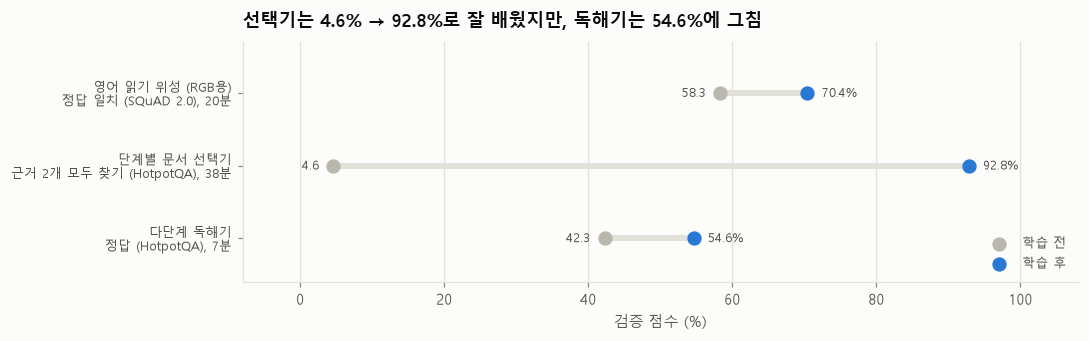

In [5]:
tr = X.satellite_training()
fig, ax = plt.subplots(figsize=(10, 3.2))
y = np.arange(len(tr))
for yi, r in zip(y, tr):
    ax.plot([r["before"], r["after"]], [yi, yi], color=V.GRID, lw=4, zorder=1)
    ax.scatter(r["before"], yi, color=V.NEUTRAL, s=70, zorder=2, label="학습 전" if yi == 0 else None)
    ax.scatter(r["after"], yi, color=V.BLUE, s=70, zorder=2, label="학습 후" if yi == 0 else None)
    ax.text(r["before"] - 2, yi, f"{r['before']:.1f}", ha="right", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
    ax.text(r["after"] + 2, yi, f"{r['after']:.1f}%", ha="left", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_yticks(y, [f"{r['part']}\n{r['metric']}, {r['minutes']:.0f}분" for r in tr], fontsize=8.5)
ax.invert_yaxis(); ax.set_xlim(-8, 108); ax.set_ylim(len(tr) - 0.4, -0.7)
ax.set_xlabel("검증 점수 (%)"); ax.grid(axis="y", visible=False)
ax.legend(fontsize=8.5, loc="lower right")
ax.set_title("선택기는 4.6% → 92.8%로 잘 배웠지만, 독해기는 54.6%에 그침", pad=10)
fig.tight_layout(); plt.show()

## 4. MuSiQue: 큰 그림

여기선 졌어. 생각 위성을 붙인 MK1은 E2B 혼자와 **비기고**(값을 못 더함), E4B 혼자에게 **졌어**.
개발용에서는 MK1이 0.56으로 E2B(0.51)보다 높았는데, 100문제짜리 차이는 잡음이었어.

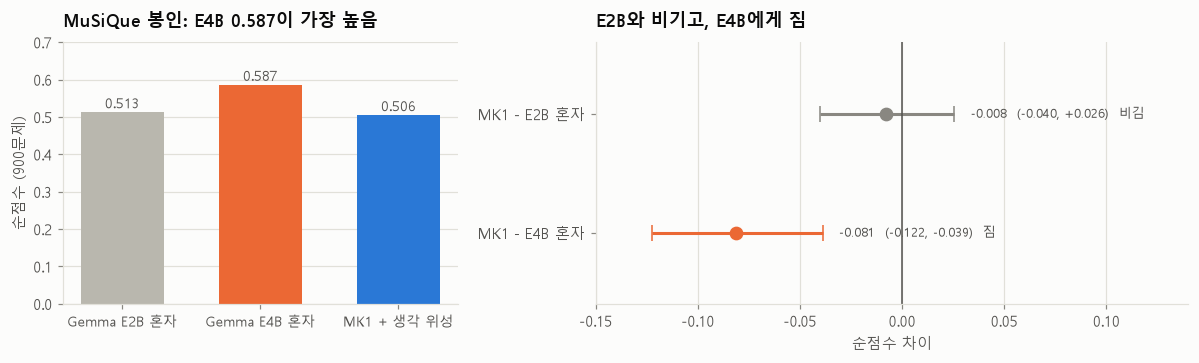

In [6]:
mo = ["e2b", "e4b", "mk1-think"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1, 1.5]})
vals = [mus["summary"][k]["net"] for k in mo]
a1.bar(range(3), vals, color=[COLORS[k] for k in mo], width=0.6)
for i, v in enumerate(vals):
    a1.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
a1.set_xticks(range(3), [X.SYSTEM_LABELS[k] for k in mo], fontsize=9); a1.set_ylim(0, 0.7)
a1.grid(axis="x", visible=False); a1.set_ylabel("순점수 (900문제)")
a1.set_title("MuSiQue 봉인: E4B 0.587이 가장 높음", pad=10)
diff_panel(a2, mus["diffs"], "E2B와 비기고, E4B에게 짐")
a2.set_xlim(-0.15, 0.14)
fig.tight_layout(); plt.show()

## 5. MuSiQue: 왜 졌나

RGB와 반대야. 여러 단계 문제에서 Gemma는 지어내기보다 **포기**를 많이 해. 답 없는 문제는 이미 97% 거절하니, 거절을 더해서 얻을 게 거의 없었어.
그런데 개발용에서 고른 "의심" 설정(근거 사슬이 없으면 Gemma 답도 거절)이 **맞는 답까지 거절**했어.

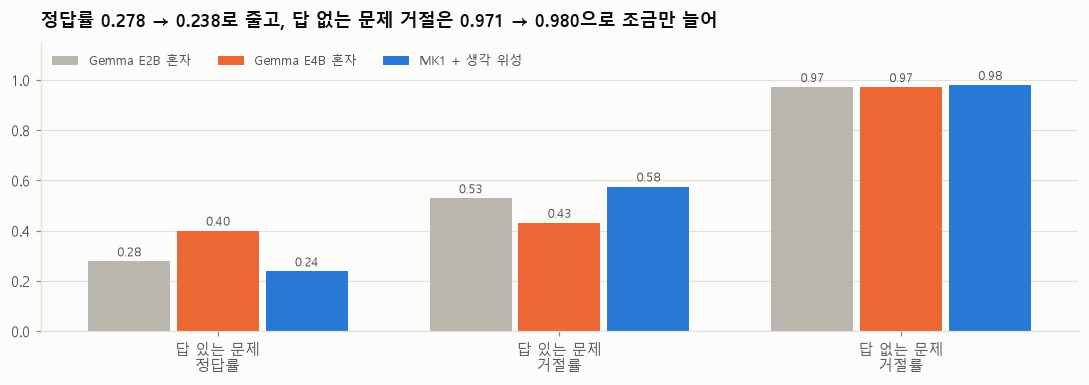

In [7]:
s = mus["summary"]
metrics = [("answerable_accuracy", "답 있는 문제\n정답률"), ("answerable_rejected", "답 있는 문제\n거절률"),
           ("unanswerable_rejection_rate", "답 없는 문제\n거절률")]
fig, ax = plt.subplots(figsize=(10, 3.6))
x = np.arange(len(metrics)); w = 0.26
for i, k in enumerate(mo):
    vals = [s[k][m] for m, _ in metrics]
    ax.bar(x + (i - 1) * w, vals, width=w - 0.02, color=COLORS[k], label=X.SYSTEM_LABELS[k])
    for xi, v in zip(x, vals):
        ax.text(xi + (i - 1) * w, v + 0.02, f"{v:.2f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [lab for _, lab in metrics]); ax.set_ylim(0, 1.15); ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5, loc="upper left", ncol=3)
ax.set_title("정답률 0.278 → 0.238로 줄고, 답 없는 문제 거절은 0.971 → 0.980으로 조금만 늘어", pad=10)
fig.tight_layout(); plt.show()

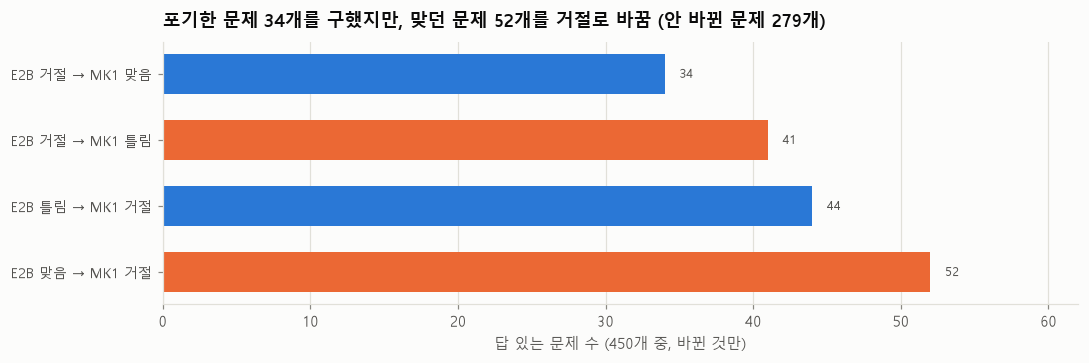

In [8]:
ch = X.musique_changes("e2b")["answerable"]
names = {"right": "맞음", "rejected": "거절", "wrong": "틀림"}
moves = [(k, v) for k, v in ch.items() if k[0] != k[1]]
moves.sort(key=lambda kv: (kv[0][1] != "right", kv[0][0] == "right"))
fig, ax = plt.subplots(figsize=(10, 3.4))
y = np.arange(len(moves))
def color(k):
    gain = {"right": 1, "rejected": 0, "wrong": -1}
    return V.BLUE if gain[k[1]] > gain[k[0]] else V.ORANGE
ax.barh(y, [v for _, v in moves], color=[color(k) for k, _ in moves], height=0.6)
for yi, (k, v) in zip(y, moves):
    ax.text(v + 1, yi, str(v), va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_yticks(y, [f"E2B {names[a]} → MK1 {names[b]}" for (a, b), _ in moves], fontsize=9)
ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.set_xlim(0, 62)
ax.set_xlabel("답 있는 문제 수 (450개 중, 바뀐 것만)")
same = sum(v for k, v in ch.items() if k[0] == k[1])
ax.set_title(f"포기한 문제 34개를 구했지만, 맞던 문제 52개를 거절로 바꿈 (안 바뀐 문제 {same}개)", pad=10)
fig.tight_layout(); plt.show()

선택기의 **근거 사슬 점수**(고른 문단 두 개 중 약한 쪽)는 답 있는/없는 문제를 꽤 잘 갈라. 답 없는 문제는 대부분 바닥에 붙어 있어.
문제는 갈라 내는 힘이 아니라, 갈라 낸 뒤 **마지막 답을 맞히는 힘**이었어.

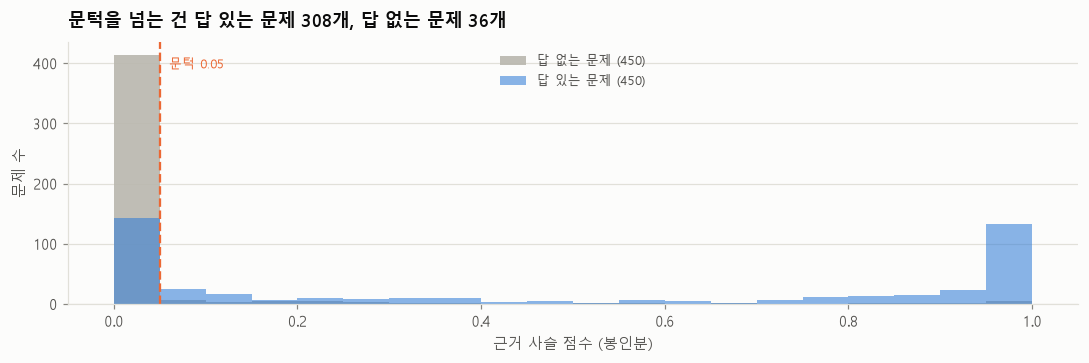

In [9]:
cs = X.chain_scores("final"); t_chain = X.think_thresholds()["thresholds"]["chain"]
bins = np.linspace(0, 1, 21)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(cs["unanswerable"], bins=bins, color=V.NEUTRAL, alpha=0.9, label="답 없는 문제 (450)")
ax.hist(cs["answerable"], bins=bins, color=V.BLUE, alpha=0.55, label="답 있는 문제 (450)")
ax.axvline(t_chain, color=V.ORANGE, lw=1.5, ls="--")
ax.text(t_chain + 0.01, ax.get_ylim()[1] * 0.9, f"문턱 {t_chain}", color=V.ORANGE, fontsize=8.5)
ax.set_xlabel("근거 사슬 점수 (봉인분)"); ax.set_ylabel("문제 수"); ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5, loc="upper center")
above_u = sum(v >= t_chain for v in cs["unanswerable"]); above_a = sum(v >= t_chain for v in cs["answerable"])
ax.set_title(f"문턱을 넘는 건 답 있는 문제 {above_a}개, 답 없는 문제 {above_u}개", pad=10)
fig.tight_layout(); plt.show()

## 6. 개발용 vs 봉인 (참고)

개발용은 작아서(RGB 140문제, MuSiQue 100문제) 흔들려. 개발용에서 MK1이 RGB에선 E4B를, MuSiQue에선 E2B를 앞서 보였는데, 봉인에선 둘 다 비김이 됐어. RGB에서 E2B보다 높은 것(+0.094)은 봉인에서도 그대로 남았어.

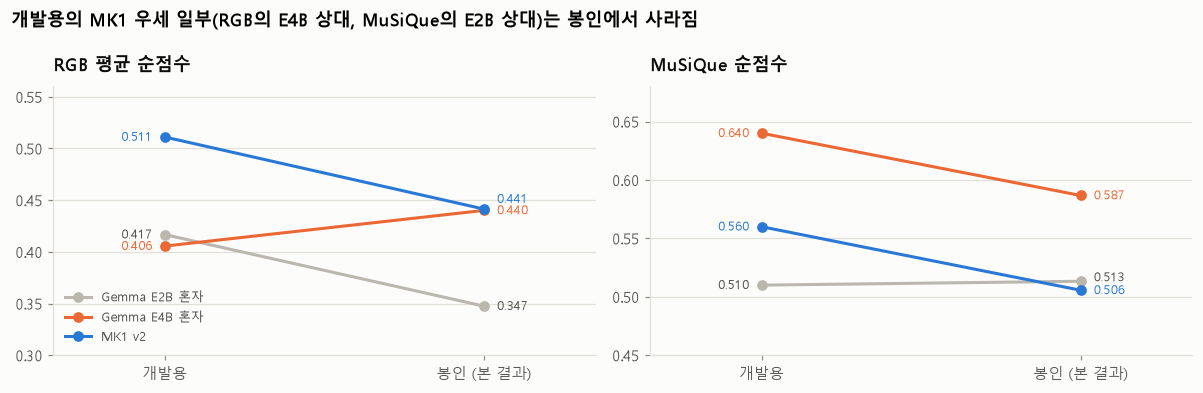

In [10]:
rd, rf = X.rgb_mean_net("dev"), rgb["mean_net"]
md_, mf = X.musique_summary("dev"), mus["summary"]
def spread(vals, gap):
    """Label positions pushed apart so near-equal values do not print on top of each other."""
    keys = sorted(vals, key=vals.get); pos = {}
    for i, k in enumerate(keys):
        pos[k] = vals[k] if i == 0 else max(vals[k], pos[keys[i - 1]] + gap)
    return pos

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (title, dev, fin, keys) in zip(axes, [
        ("RGB 평균 순점수", rd, rf, order),
        ("MuSiQue 순점수", {k: md_[k]["net"] for k in mo}, {k: mf[k]["net"] for k in mo}, mo)]):
    for k in keys:
        ax.plot([0, 1], [dev[k], fin[k]], color=COLORS[k], marker="o", lw=2, label=X.SYSTEM_LABELS[k])
    for xpos, ha, vals in [(1.04, "left", fin), (-0.04, "right", dev)]:
        placed = spread({k: vals[k] for k in keys}, gap=0.011)
        for k in keys:
            ax.text(xpos, placed[k], f"{vals[k]:.3f}", va="center", ha=ha, fontsize=8.5,
                    color=COLORS[k] if k != "e2b" else V.TEXT_SECONDARY)
    ax.set_xticks([0, 1], ["개발용", "봉인 (본 결과)"]); ax.set_xlim(-0.35, 1.35); ax.grid(axis="x", visible=False)
    ax.set_title(title, pad=10)
axes[0].legend(fontsize=8.5, loc="lower left")
axes[0].set_ylim(0.3, 0.56); axes[1].set_ylim(0.45, 0.68)
fig.suptitle("개발용의 MK1 우세 일부(RGB의 E4B 상대, MuSiQue의 E2B 상대)는 봉인에서 사라짐", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()

## 7. 정리

| | RGB (문서 보고 답하기) | MuSiQue (여러 단계 생각) |
|---|---|---|
| MK1 − E2B 혼자 | **+0.094, 이김** | −0.008, 비김 |
| MK1 − E4B 혼자 | +0.001, 비김 | **−0.081, 짐** |

- **엮기가 이기는 곳은 판단**이야. 단일 LLM이 지어내는 시험(RGB)에서는 판단 위성이 지어낸 답을 막아서 점수를 올렸어.
- **엮기가 지는 곳은 넓은 추론**이야. 단일 LLM이 포기하는 시험(MuSiQue)에서는 거절을 더해 봐야 얻을 게 없고, 포기한 문제를 구하려면 마지막 답을 맞히는 힘이 필요해. 0.28B 독해기(HotpotQA 54.6%)로는 4B급 LLM의 추론을 따라가지 못했어.
- 다음에 할 일(RGB 쪽): 근거를 여러 문서에서 합치기, 거짓 문서를 위한 지식 위성, 문턱 대신 학습된 작은 판정기. 둘 다 봉인분은 이미 썼으니, 새 시험으로 판정해야 해.